In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import (
    MF,
    ItemKNN,
    UserKNN,
    NMF,
    BPR,
    LightGCN,
    SVD,
    MostPop,
    VAECF,
    NeuMF,
)
import pandas as pd
import numpy as np
import random

# import matha
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/yelp/indexed_interactions.csv",
    sep="\t",
    header=0,
    names=["itemID", "Category", "userID", "Rating", "Gender"],
)
rating_data = rating_data_pd[["userID", "itemID", "Rating"]].to_numpy()
rating_data.__len__()
rating_data_pd

,itemID,Category,userID,Rating,Gender
0,0,Food & Restaurants|Drinks & Spirits,0,5,F
1,0,Food & Restaurants|Drinks & Spirits,1,4,F
2,0,Food & Restaurants|Drinks & Spirits,2,5,F
3,0,Food & Restaurants|Drinks & Spirits,3,3,M
4,0,Food & Restaurants|Drinks & Spirits,4,3,F
...,...,...,...,...,...
97986,1271,Food & Restaurants,1060,3,F
97987,1271,Food & Restaurants,161,2,M
97988,1271,Food & Restaurants,25,3,F
97989,1271,Food & Restaurants,280,4,F


In [3]:
restaurants = pd.read_csv(
    "./cornac/data_c/yelp/i_id_mapping.csv",
    sep="\t",
    header=0,
    names=["item_id", "Category", "itemID"],
)
restaurants = restaurants.sort_values(by="itemID")

unique_categories = [
    "Active Life & Fitness",
    "Arts & Entertainment",
    "Automotive",
    "Bars & Nightlife",
    "Coffee,Tea & Desserts",
    "Drinks & Spirits",
    "Education & Learning",
    "Event Services",
    "Family & Kids",
    "Food & Restaurants",
    "Health & Beauty",
    "Home & Garden",
    "Miscellaneous",
    "Outdoor Activities",
    "Public Services & Community",
    "Shopping & Fashion",
    "Specialty Food & Groceries",
    "Sports & Recreation",
    "Technology & Electronics",
    "Travel & Transportation",
    "Asian",
]
for c in unique_categories:
    restaurants[c] = 0
for index, row in restaurants.iterrows():
    cats = row["Category"].split("|")
    for cat in cats:
        restaurants.at[index, cat] = 1

cat = restaurants[unique_categories]
# cat[:1]
item_features_numpy = cat.to_numpy()
item_features = {
    str(item_id): {"category_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
# ids = list(range(0, 3416))

In [4]:
restaurants

,item_id,Category,itemID,Active Life & Fitness,Arts & Entertainment,Automotive,Bars & Nightlife,"Coffee,Tea & Desserts",Drinks & Spirits,Education & Learning,...,Home & Garden,Miscellaneous,Outdoor Activities,Public Services & Community,Shopping & Fashion,Specialty Food & Groceries,Sports & Recreation,Technology & Electronics,Travel & Transportation,Asian
0,34,Food & Restaurants|Drinks & Spirits,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,250,Food & Restaurants|Drinks & Spirits,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,759,Asian|Food & Restaurants,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1085,Food & Restaurants,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1122,Travel & Transportation,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,188255,Food & Restaurants,1267,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1268,188310,Food & Restaurants,1268,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1269,188449,Food & Restaurants|Bars & Nightlife,1269,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1270,188454,Food & Restaurants,1270,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
users = pd.read_csv(
    "./cornac/data_c/yelp/u_id_mapping.csv",
    sep="\t",
    header=0,
    names=["user_id", "Gender", "userID"],
)
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
users = users.sort_values(by="userID")
users = users[["Gender", "userID"]]

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
# print(item_features_numpy.shape)

(1316, 2)


In [6]:
# users
user_features_numpy[:, 0]

array([1, 1, 1, ..., 1, 0, 0])

In [7]:
item_features_numpy

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [8]:
dataset = rating_data
unique_categories.__len__()

21

In [9]:
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
    fmt="UIR",
)
models = []
x = []
alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
# alpha_values = [0]
for i in range(len(alpha_values)):
    # learning
    models.append(
        VAECF(
            k=20,
            autoencoder_structure=[60,32],
            act_fn="relu",
            likelihood="bern",
            n_epochs=50,
            batch_size=128,
            learning_rate=0.0005,
            alpha=alpha_values[i],
            top_k=50,
            beta=1,
            name=f"a={alpha_values[i]} vae",
            seed=123,
            verbose=True,
            # early_stopping=True
        )
    )


# Early stopping:
# - best epoch = 5, stopped epoch = 15
# - best monitored value = 0.062177 (delta = 0.000021)


cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, prec, hr, mrr, map, f1]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 1315, 1315, 1315]), array([   0,    1,    2, ..., 1030,  793, 1250]), array([4., 5., 2., ..., 4., 5., 5.]))
Number of users = 1316
Number of items = 1272
Number of ratings = 67470
Max rating = 5.0
Min rating = 1.0
Global mean = 3.9
Global mean Imolicit= 1.0
::::::::
OrderedDict([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29), (30, 30), (31, 31), (32, 32), (33, 33), (34, 34), (35, 35), (36, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 41), (42, 42), (43, 43), (44, 44), (45, 45), (46, 46), (47, 47), (48, 48), (49, 49), (50, 50), (51, 51), (52, 52), (53, 53), (54, 54), (55, 55), (56, 56), (57, 57), (58, 58), (59, 5

100%|██████████| 50/50 [00:04<00:00, 10.23it/s, loss=1.71]


[884.9312744140625, 882.5948486328125, 880.4240112304688, 878.087890625, 876.0466918945312, 874.0122680664062, 871.3710327148438, 869.6033935546875, 866.867431640625, 863.7490234375, 861.4684448242188, 861.489990234375, 857.3489990234375, 855.0188598632812, 851.5498046875, 847.2013549804688, 845.3406372070312, 841.9681396484375, 837.9872436523438, 834.635009765625, 829.8966064453125, 824.497802734375, 825.3953857421875, 819.5279541015625, 814.3600463867188, 808.9532470703125, 805.1406860351562, 799.8201904296875, 791.5916748046875, 785.3629760742188, 774.143798828125, 771.1220703125, 761.093505859375, 753.7487182617188, 743.2649536132812, 731.014404296875, 724.6583862304688, 710.3460693359375, 698.31005859375, 681.3291625976562, 671.1875610351562, 660.19873046875, 638.6788330078125, 620.4563598632812, 695.5601806640625, 594.368408203125, 577.14013671875, 553.61083984375, 531.6808471679688, 516.72412109375, 496.90484619140625, 496.86541748046875, 474.7626953125, 441.94061279296875, 415.

Ranking: 100%|██████████| 1316/1316 [00:01<00:00, 1055.02it/s]



[a=0.1 vae] Training started!


...


[a=0.6 vae] Training started!


100%|██████████| 50/50 [02:25<00:00,  2.91s/it, loss=1.85]


[614.4464111328125, 612.8690185546875, 610.7343139648438, 609.7215576171875, 608.33935546875, 607.0780639648438, 605.4074096679688, 604.7245483398438, 603.4322509765625, 601.8458251953125, 599.8695068359375, 603.524658203125, 599.2462158203125, 597.3697509765625, 596.45068359375, 593.788818359375, 592.988037109375, 591.5423583984375, 589.037841796875, 588.2357177734375, 586.3565063476562, 583.9541625976562, 590.08642578125, 582.2225952148438, 580.3916625976562, 578.5669555664062, 575.9895629882812, 574.0321655273438, 569.2587280273438, 568.8934326171875, 562.4634399414062, 564.28076171875, 556.91943359375, 567.2911376953125, 553.421142578125, 549.7811279296875, 548.901611328125, 542.5435180664062, 541.947998046875, 533.5745849609375, 532.2762451171875, 530.5, 518.335693359375, 511.46014404296875, 558.9798583984375, 508.1447448730469, 505.36767578125, 493.7597351074219, 486.6123046875, 484.04608154296875, 482.5806884765625, 483.51629638671875, 469.5813293457031, 456.6675720214844, 439.3

Ranking: 100%|██████████| 1316/1316 [00:01<00:00, 1172.48it/s]


VALIDATION:
...
          |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
--------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
a=0 vae   | 0.6396 | 0.0343 |      0.6094 | 0.0328 | 0.1128 |  0.0765 |       0.0207 |    0.1324 |   1.2510
a=0.1 vae | 0.6383 | 0.0341 |      0.6064 | 0.0327 | 0.1136 |  0.0760 |       0.0205 |    0.1307 |   1.6355
a=0.2 vae | 0.6343 | 0.0338 |      0.6064 | 0.0323 | 0.1133 |  0.0752 |       0.0203 |    0.1295 |   1.3553
a=0.3 vae | 0.6280 | 0.0335 |      0.6049 | 0.0316 | 0.1119 |  0.0741 |       0.0202 |    0.1278 |   1.3535
a=0.4 vae | 0.6231 | 0.0328 |      0.5957 | 0.0308 | 0.1091 |  0.0724 |       0.0198 |    0.1255 |   1.1922
a=0.5 vae | 0.6157 | 0.0315 |      0.5714 | 0.0291 | 0.1045 |  0.0686 |       0.0190 |    0.1194 |   1.4809
a=0.6 vae | 0.6105 | 0.0308 |      0.5669 | 0.0269 | 0.0920 |  0.0644 |       0.0186 |    0.1161 |   1.1277

TEST:
...


In [10]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
print(len(user_ids))
print(len(item_ids))
print(user_ids)
print(item_ids)

1316
1272
[   0    1    2 ... 1313 1314 1315]
[0 1 2 ... 1269 1270 1271]


In [26]:

def extract_columns(table: str, col_names: tuple):
    """
    Extract columns named in col_names from the ASCII table in `table`.
    Returns list of lists corresponding to each column.
    """
    lines = [ln for ln in table.splitlines() if ln.strip() != ""]
    # find header line (contains known header tokens like 'RMSE' or 'HitRatio')
    header_idx = None
    for i, ln in enumerate(lines):
        if 'AUC' in ln and 'HitRatio' in ln:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError("Header line not found in table")

    # find separator line after header (line with dash or +)
    sep_idx = None
    for j in range(header_idx+1, len(lines)):
        if set(lines[j].strip()) <= set("-+ "):
            sep_idx = j
            break
    if sep_idx is None:
        # fallback: assume header_idx is followed immediately by data
        sep_idx = header_idx

    header_line = lines[header_idx]
    data_lines = lines[sep_idx+1:]

    # split header into column names
    headers = [h.strip() for h in header_line.split('|')]
    # find indices for requested columns
    idxs = []
    for cname in col_names:
        try:
            idx = headers.index(cname)
        except ValueError:
            # try more tolerant matching (case-insensitive / substring)
            found = False
            for k, h in enumerate(headers):
                if cname.lower() in h.lower():
                    idxs.append(k)
                    found = True
                    break
            if not found:
                raise ValueError(f"Column '{cname}' not found in header: {headers}")
        else:
            idxs.append(idx)

    # parse data rows
    results = [[] for _ in col_names]
    for dl in data_lines:
        parts = [p.strip() for p in dl.split('|')]
        # skip lines that don't have enough columns
        if len(parts) <= max(idxs):
            continue
        for out_list, idx in zip(results, idxs):
            val_str = parts[idx]
            # remove accidental commas and convert to float
            try:
                val = float(val_str.replace(',', ''))
            except ValueError:
                # if there are extra spaces or non-numeric, try to extract numeric substring
                import re
                m = re.search(r"[-+]?\d*\.\d+|\d+", val_str)
                if m:
                    val = float(m.group(0))
                else:
                    raise
            out_list.append(val)
    return results



In [13]:
# models[0].save("./saved")
import pickle

with open("yelp100k_vaecf_gr.pkl", "wb") as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(models, f, pickle.HIGHEST_PROTOCOL)

In [27]:
perf_string = """
                   |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
--------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 vae   | 0.6384 | 0.0581 |      0.8131 | 0.0453 | 0.1825 |  0.0985 |       0.0399 |    0.1343 |    5.8624 |   1.5401
a=0.1 vae | 0.6373 | 0.0573 |      0.8108 | 0.0452 | 0.1884 |  0.0979 |       0.0393 |    0.1322 |  168.5034 |   1.8494
a=0.2 vae | 0.6339 | 0.0569 |      0.8017 | 0.0446 | 0.1877 |  0.0971 |       0.0391 |    0.1312 |  158.3074 |   1.6715
a=0.3 vae | 0.6289 | 0.0566 |      0.7986 | 0.0437 | 0.1839 |  0.0959 |       0.0389 |    0.1304 |  136.3533 |   1.7876
a=0.4 vae | 0.6244 | 0.0552 |      0.7926 | 0.0427 | 0.1829 |  0.0937 |       0.0379 |    0.1276 |  136.7852 |   1.7008
a=0.5 vae | 0.6172 | 0.0529 |      0.7758 | 0.0409 | 0.1776 |  0.0893 |       0.0365 |    0.1216 |  136.0371 |   1.5006
a=0.6 vae | 0.6120 | 0.0529 |      0.7796 | 0.0393 | 0.1652 |  0.0870 |       0.0366 |    0.1215 |  145.5136 |   1.3327

"""
hit_list, ndcg_list = extract_columns(perf_string, ("HitRatio@50", "NDCG@50"))
print("HitRatio@50:", hit_list)
print("NDCG@50:   ", ndcg_list)

HitRatio@50: [0.8131, 0.8108, 0.8017, 0.7986, 0.7926, 0.7758, 0.7796]
NDCG@50:    [0.0985, 0.0979, 0.0971, 0.0959, 0.0937, 0.0893, 0.087]


In [14]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
item_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [15]:
np.save("reco_matrix_vae_yelp_100k_gr.npy", reco_matrix)
# np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
# np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all_vae_yelp_100k_gr.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [16]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMapEdited import GenreMapEdited
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision


top_k = 50
###intialize them
gp = GenrePrecision(users, unique_categories, top_k)
gr = GenreRecall(users, unique_categories, top_k)
gm = GenreMapEdited(users, unique_categories, top_k)
gndcg = GenreNDCG(users, unique_categories, top_k)
gmrr = GenreMRR(users, unique_categories, top_k)

In [17]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(reco_matrix)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], restaurants))
    model_grs.append(gr.compute(reco_matrix[i], restaurants))
    model_gms.append(gm.compute(reco_matrix[i], restaurants))
    model_gdcgs.append(gndcg.compute(reco_matrix[i], restaurants))
    model_gmrrs.append(gmrr.compute(reco_matrix[i], restaurants))


restaurants = restaurants.rename(columns={"Category": "genres"})
# ####IR Metrics####
# ####Rprecision####
model_grps = []
# for i in range(len(models)):
#     model_grps.append(grp.compute(reco_matrix_top_r[i], restaurants_df, restaurants))


In [18]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = restaurants[unique_categories].div(restaurants[unique_categories].sum(axis=1), axis=0)
movies_df = movies_df[unique_categories].sum()
import math
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(reco_matrix), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(reco_matrix)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_categories, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [19]:
model_grps = []
for i in range(len(reco_matrix)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, restaurants))

        Active Life & Fitness  Arts & Entertainment  Automotive  \
Gender                                                            
0                         0.0              0.071475         0.0   
1                         0.0              0.071498         0.0   

        Bars & Nightlife  Coffee,Tea & Desserts  Drinks & Spirits  \
Gender                                                              
0               0.120896               0.043176          0.013649   
1               0.120961               0.042840          0.013649   

        Education & Learning  Event Services  Family & Kids  \
Gender                                                        
0                        0.0        0.048253            0.0   
1                        0.0        0.048423            0.0   

        Food & Restaurants  ...  Home & Garden  Miscellaneous  \
Gender                      ...                                 
0                 0.527823  ...            0.0            0.0   
1     

In [21]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(reco_matrix))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(reco_matrix))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(reco_matrix))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(reco_matrix))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(reco_matrix))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(reco_matrix))]


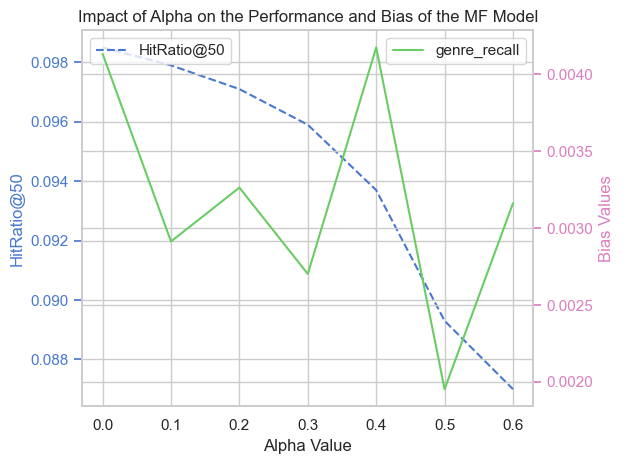

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

alpha_values = [0, 0.1,0.2,0.3,0.4,0.5,0.6]

x = alpha_values
upper_bound = len(alpha_values)
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

fig, ax1 = plt.subplots()

ax1.plot(x[0:upper_bound], ndcg_list[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
# ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound], linestyle="dotted", color=pastel_palette[0], label="RMSE")
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0])
ax1.tick_params(axis="y", colors=pastel_palette[0])
ax2 = ax1.twinx()
# ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
# ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
# ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
# ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
# ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6])
ax2.tick_params(axis="y", colors=pastel_palette[6])
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Impact of Alpha on the Performance and Bias of the MF Model")
plt.tight_layout()
plt.show()


In [31]:
all_bias = [gp_sum, gr_sum, gm_sum, gdcg_sum, gmrr_sum, grp_sum]
chosen_alpha =3
for i in range(len(all_bias)):
    print(all_bias[i][chosen_alpha])
print(f"ndcg at 0 {ndcg_list[0]} hr at 0 {hit_list[0]}")
print(f"ndcg at chosen a {ndcg_list[chosen_alpha]} hr at chosen a {hit_list[chosen_alpha]}")

0.002252207832051281
0.0027020980123300727
0.0001507944298658803
0.00043055217609822536
0.00016475548536850569
0.001257205287793277
ndcg at 0 0.0985 hr at 0 0.8131
ndcg at chosen a 0.0959 hr at chosen a 0.7986


In [34]:
ndcg_list

[0.0985, 0.0979, 0.0971, 0.0959, 0.0937, 0.0893, 0.087]

In [ ]:
|